In [1]:
import pandas as pd 
import numpy as np 
import statsmodels.api as sm

In [2]:
results = pd.read_csv("recidivism_results/pair_results_size100_allpairs.csv")
len(results)

99606

In [3]:
def get_adj_risk_score():
    results = pd.read_csv("recidivism_results/pair_results_size100_allpairs.csv")
    results['response'] = np.where((results['response'] == "Person 1") | (results['response'] == "Person 2"), results['response'], "Removed response")

    rating_counts_df = pd.concat([
    results.loc[results['response'] == 'Person 1', 'id.x'],
    results.loc[results['response'] == 'Person 2', 'id.y']
    ])

    rate_df = rating_counts_df.value_counts().reset_index()
    rate_df.columns = ['id', 'risk_score']

    unknown_counts_df = pd.concat([
    results.loc[results['response'] == 'Removed response', 'id.x'],
    results.loc[results['response'] == 'Removed response', 'id.y']
    ])

    unknown_df = unknown_counts_df.value_counts().reset_index()
    unknown_df.columns = ['id', 'unknown_count']


    judges = pd.read_csv("preprocessed_data/judges_pairs_preprocessed_unpaired_size100_allpairs.csv")
    results_df = pd.merge(pd.merge(judges, rate_df, on = 'id', how = 'left'), unknown_df, on = 'id', how = 'left')
    results_df['risk_score'] = results_df['risk_score'].fillna(0)
    results_df['unknown_count'] = results_df['unknown_count'].fillna(0)
    results_df['risk_score_adj'] = results_df['risk_score']/((results_df['pair_group_size']-1)*2 - results_df['unknown_count'])

    return results_df

## Initial Results

In [4]:
judges = pd.read_csv("judges.csv")
judges['id'] = range(1, len(judges) + 1)
judges = judges[['id', 'calendar1', 'calendar2', 'calendar3', 'calendar4', 'calendar5', 'calendar6', 'calendar7', 'calendar8']]

judges_results = get_adj_risk_score() 
judges_results = pd.merge(judges_results, judges, on = 'id', how = 'left')

In [5]:
import statsmodels.api as sm

# no pair score
judges_results['gender_mod'] = np.where(judges_results['gender'] =="male", 0, 1)
judges_results['nonblack_mod'] = np.where(judges_results['nonblack'] == "not Black", 0, 1)
y = judges_results[['laterarr']]
X = judges_results[['oob_preds', 'age', 'gender_mod', 'nonblack_mod', 'marijuana', 'cocaine', 'crack', 'heroin', 'pcp', 'otherdrug', 'nondrug', 'priorarr', 'priorfelarr', 'priordrugarr', 'priorfeldrugarr', 'priorcon', 'priorfelcon', 'priordrugcon', 'priorfeldrugcon', 'pwid', 'dist', 'calendar1', 'calendar2', 'calendar3', 'calendar4', 'calendar5', 'calendar6', 'calendar7', 'calendar8']]
X = sm.add_constant(X)

model1 = sm.Logit(y, X).fit()

print(model1.summary())

Optimization terminated successfully.
         Current function value: 0.642444
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               laterarr   No. Observations:                 1003
Model:                          Logit   Df Residuals:                      973
Method:                           MLE   Df Model:                           29
Date:                Thu, 13 Aug 2026   Pseudo R-squ.:                 0.07128
Time:                        09:24:26   Log-Likelihood:                -644.37
converged:                       True   LL-Null:                       -693.83
Covariance Type:            nonrobust   LLR p-value:                 1.461e-09
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.5524      0.494      3.146      0.002       0.585       2.520
oob_preds     

In [30]:
table = model1.summary2().tables[1]

result = table[["Coef.", "Std.Err.", "P>|z|"]].round(3)
print(result)

                 Coef.  Std.Err.  P>|z|
const            1.552     0.494  0.002
oob_preds        1.276     0.369  0.001
age             -0.051     0.008  0.000
gender_mod      -0.212     0.222  0.338
nonblack_mod    -1.128     0.476  0.018
marijuana        0.433     0.239  0.070
cocaine         -0.069     0.242  0.774
crack            0.127     0.271  0.640
heroin           0.360     0.259  0.165
pcp              0.573     0.387  0.139
otherdrug       -0.432     0.458  0.345
nondrug          0.033     0.202  0.869
priorarr        -0.433     0.317  0.172
priorfelarr      0.578     0.278  0.038
priordrugarr     0.054     0.286  0.850
priorfeldrugarr -0.576     0.299  0.054
priorcon         0.213     0.314  0.497
priorfelcon     -0.452     0.310  0.144
priordrugcon     0.273     0.317  0.389
priorfeldrugcon  0.386     0.336  0.251
pwid             0.138     0.254  0.586
dist             0.193     0.259  0.456
calendar1       -0.878     0.289  0.002
calendar2       -0.892     0.293  0.002


In [6]:
X2 = judges_results[['oob_preds', 'risk_score_adj', 'age', 'gender_mod', 'nonblack_mod', 'marijuana', 'cocaine', 'crack', 'heroin', 'pcp', 'otherdrug', 'nondrug', 'priorarr', 'priorfelarr', 'priordrugarr', 'priorfeldrugarr', 'priorcon', 'priorfelcon', 'priordrugcon', 'priorfeldrugcon', 'pwid', 'dist', 'calendar1', 'calendar2', 'calendar3', 'calendar4', 'calendar5', 'calendar6', 'calendar7', 'calendar8']]
X2= sm.add_constant(X2)
y = judges_results[['laterarr']]

model2 = sm.Logit(y, X2).fit()

print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.642409
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               laterarr   No. Observations:                 1003
Model:                          Logit   Df Residuals:                      972
Method:                           MLE   Df Model:                           30
Date:                Thu, 13 Aug 2026   Pseudo R-squ.:                 0.07133
Time:                        09:24:28   Log-Likelihood:                -644.34
converged:                       True   LL-Null:                       -693.83
Covariance Type:            nonrobust   LLR p-value:                 2.690e-09
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.5759      0.501      3.143      0.002       0.593       2.559
oob_preds     

In [31]:
table = model2.summary2().tables[1]

result = table[["Coef.", "Std.Err.", "P>|z|"]].round(3)
print(result)

                 Coef.  Std.Err.  P>|z|
const            1.576     0.501  0.002
oob_preds        1.253     0.378  0.001
risk_score_adj  -0.380     1.442  0.792
age             -0.051     0.008  0.000
gender_mod      -0.239     0.244  0.327
nonblack_mod    -1.135     0.477  0.017
marijuana        0.422     0.243  0.083
cocaine         -0.044     0.261  0.867
crack            0.161     0.301  0.592
heroin           0.392     0.287  0.172
pcp              0.594     0.396  0.133
otherdrug       -0.416     0.462  0.368
nondrug          0.054     0.216  0.804
priorarr        -0.395     0.348  0.256
priorfelarr      0.616     0.313  0.049
priordrugarr     0.078     0.300  0.795
priorfeldrugarr -0.574     0.299  0.054
priorcon         0.229     0.319  0.473
priorfelcon     -0.333     0.550  0.545
priordrugcon     0.289     0.323  0.371
priorfeldrugcon  0.383     0.337  0.256
pwid             0.141     0.255  0.578
dist             0.191     0.259  0.460
calendar1       -0.886     0.290  0.002


## Treatment Effects and Variances

In [7]:
cols = [f"calendar{i}" for i in range(1, 9)]

judges_results["judge"] = (
    judges_results[cols]
    .idxmax(axis=1)         
    .str.extract(r"(\d+)")
    .astype(int)
)

judges_results.loc[judges_results[cols].sum(axis=1) == 0, "judge"] = 9

In [8]:
def get_variance(df, p, pred_type = "basic", outcome = "laterarr", treatment = "treatment"):
    df['m'] = p * df[f'y_it_{pred_type}'] + (1- p) * df[f'y_ic_{pred_type}']

    nc = len(df) - sum(df[f'{treatment}'])
    nt = sum(df[f'{treatment}'])
    N = len(df)

    ec2 = 1/nc * sum((1 - df[f'{treatment}']) * (df[f'y_ic_{pred_type}'] - df[f'{outcome}'])**2)
    et2 = 1/nt * sum(df[f'{treatment}'] * (df[f'y_it_{pred_type}'] - df[f'{outcome}'])**2)


    var_est = 1/N * (p/(1-p) * ec2 + (1-p)/p * et2 + 2 * (ec2 * et2)**0.5)
    return var_est


def get_treatment_est(df,p, pred_type = "basic"):
    df['m'] = p * df[f'y_it_{pred_type}'] + (1- p) * df[f'y_ic_{pred_type}']
    N = len(df)
    treatment_est = 1/N * sum((df['treatment'] * (df['laterarr'] - df['m']))/p) - 1/N * sum(((1-df['treatment']) * (df['laterarr'] - df['m']))/(1-p))
    return treatment_est


In [9]:
def get_pairwise_var_no_adj(judge1, judge2):

    df1 = judges_results[(judges_results['judge'] == judge1)].copy()
    df2 = judges_results[(judges_results['judge'] == judge2)].copy()
    mean_treatment = df1['laterarr'].mean()
    mean_control = df2['laterarr'].mean()
    nt = len(df1)
    nc = len(df2)

    var = sum((df1['laterarr'] - mean_treatment)**2)/((nt-1)*nt) + sum((df2['laterarr'] - mean_control)**2)/((nc-1)*nc)
    return var**0.5

table_no_adj = pd.DataFrame(
    "",
    index=range(1, 10),
    columns=range(1, 10)
)

for i in range(1, 10):
    for j in range(i+1, 10):  # Only upper triangle
        se1 = get_pairwise_var_no_adj(i, j)
        table_no_adj.loc[i, j] = se1

print(table_no_adj)

  1         2         3         4         5         6         7         8  \
1    0.065561  0.064428  0.063999  0.064855  0.068634   0.06617  0.067701   
2              0.065737  0.065317  0.066155  0.069864  0.067446  0.068948   
3                         0.06418  0.065033  0.068802  0.066345  0.067872   
4                                  0.064608  0.068401  0.065929  0.067465   
5                                            0.069202   0.06676  0.068277   
6                                                      0.070437  0.071876   
7                                                                0.069528   
8                                                                           
9                                                                           

          9  
1   0.06433  
2  0.065641  
3   0.06451  
4  0.064082  
5  0.064936  
6  0.068711  
7   0.06625  
8  0.067779  
9            


In [10]:
def get_pairwise_var_linear(judge1, judge2, covariates):
    df = judges_results[(judges_results['judge'] == judge1) | (judges_results['judge'] == judge2)].copy()
    df['treatment'] = np.where(df['judge'] == judge1, 1, 0)
    df = df[covariates + ['laterarr', 'treatment']].reset_index()
    y = df["laterarr"]
    X1 = df[covariates + ['treatment']]
    X1= sm.add_constant(X1) # do I have two constants here

    for i in df.index:
        X_withouti = sm.add_constant(X1.drop(index = i))
        y_withouti = np.delete(y, i)

        model_withouti = sm.OLS(y_withouti, X_withouti).fit()

        observation_it = X1.iloc[[i]]
        observation_it.loc[:,'treatment'] = 1 

        observation_ic = X1.iloc[[i]]
        observation_ic.loc[:,'treatment'] = 0

        y_it = model_withouti.predict(observation_it).iloc[0]
        y_ic = model_withouti.predict(observation_ic).iloc[0]
    
        df.loc[i, 'y_ic_cov'] = y_ic
        df.loc[i, 'y_it_cov'] = y_it

    var_with_cov = get_variance(df, p = 0.5, pred_type = "cov") # variance without risk score
    return var_with_cov**0.5

In [12]:
rows = []

n = len(table_no_adj)

for i in range(1,10):
    for j in range(i + 1, n+1):   # upper triangle only
        rows.append({
            "group1": i ,
            "group2": j,
            "no adjustment": table_no_adj.loc[i][j],
            "age only": get_pairwise_var_linear(i,j, ["age"]),
            "all rct": get_pairwise_var_linear(i,j, ['age', 'gender_mod', 'nonblack_mod', 'marijuana', 'cocaine', 'crack', 'heroin', 'pcp', 'otherdrug', 'nondrug', 'priorarr', 'priorfelarr', 'priordrugarr', 'priorfeldrugarr', 'priorcon','priorfelcon', 'priordrugcon', 'priorfeldrugcon', 'pwid', 'dist',
         'oob_preds']),
            "all rct + LLM": get_pairwise_var_linear(i,j, ['age', 'gender_mod', 'nonblack_mod', 'marijuana', 'cocaine', 'crack', 'heroin', 'pcp', 'otherdrug', 'nondrug', 'priorarr', 'priorfelarr', 'priordrugarr', 'priorfeldrugarr', 'priorcon','priorfelcon', 'priordrugcon', 'priorfeldrugcon', 'pwid', 'dist',
         'oob_preds','risk_score_adj'])
        })

se_df = pd.DataFrame(rows)
print(se_df)

    group1  group2  no adjustment  age only   all rct  all rct + LLM
0        1       2       0.065561  0.065552  0.067735       0.068124
1        1       3       0.064428  0.062372  0.065884       0.066198
2        1       4       0.063999  0.063089  0.064410       0.064673
3        1       5       0.064855  0.063342  0.065638       0.065801
4        1       6       0.068634  0.067617  0.071151       0.071524
5        1       7       0.066170  0.064385  0.067431       0.067507
6        1       8       0.067701  0.066867  0.068946       0.069304
7        1       9       0.064330  0.063450  0.065609       0.065896
8        2       3       0.065737  0.065089  0.067385       0.067558
9        2       4       0.065317  0.065361  0.064572       0.064777
10       2       5       0.066155  0.065917  0.064952       0.065265
11       2       6       0.069864  0.070026  0.072734       0.073131
12       2       7       0.067446  0.067105  0.070087       0.070443
13       2       8       0.068948 

In [32]:
round(se_df, 3)

,group1,group2,no adjustment,age only,all rct,all rct + LLM
0,1,2,0.066,0.066,0.068,0.068
1,1,3,0.064,0.062,0.066,0.066
2,1,4,0.064,0.063,0.064,0.065
3,1,5,0.065,0.063,0.066,0.066
4,1,6,0.069,0.068,0.071,0.072
5,1,7,0.066,0.064,0.067,0.068
6,1,8,0.068,0.067,0.069,0.069
7,1,9,0.064,0.063,0.066,0.066
8,2,3,0.066,0.065,0.067,0.068
9,2,4,0.065,0.065,0.065,0.065


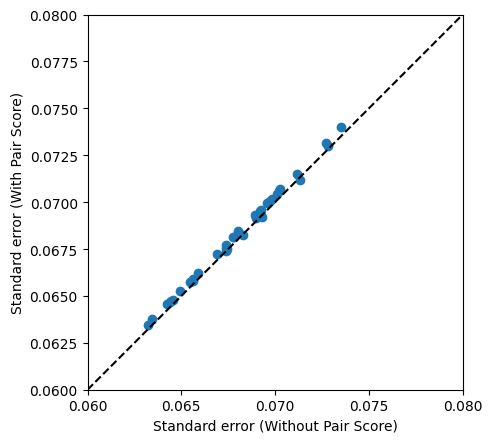

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))

plt.scatter(se_df["all rct"], se_df["all rct + LLM"])

# 45-degree line
lims = [
   0.06, 0.08
]
plt.plot(lims, lims, "k--")

plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect("equal", adjustable="box")
plt.xticks([0.060, 0.065, 0.070, 0.075, 0.080])

plt.xlabel("Standard error (Without Pair Score)")
plt.ylabel("Standard error (With Pair Score)")

plt.savefig("judges_scatterplot.pdf", bbox_inches="tight")
plt.savefig("judges_scatterplot.jpg", dpi = 600, bbox_inches="tight")

plt.tight_layout()
plt.show()

# Analysis of Adjusted Pair Score

In [14]:
print(judges_results['risk_score_adj'].mean())
print(judges_results['risk_score_adj'].std())

0.49999196740974905
0.26936179522060466


In [15]:
judges_results['risk_score_adj'].corr(judges_results['laterarr'])

np.float64(-0.022990164482323383)

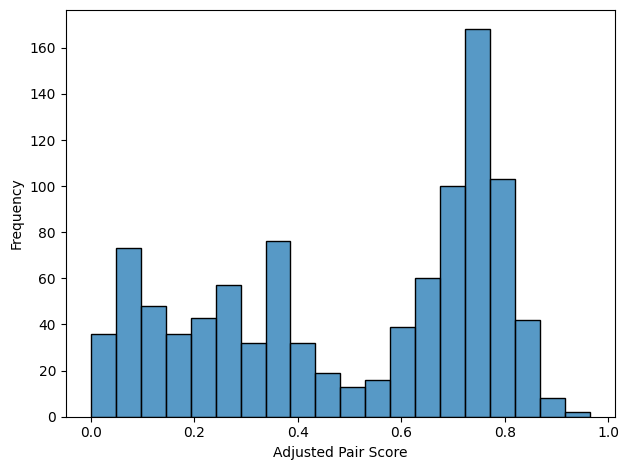

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(judges_results['risk_score_adj'], bins=20)

plt.xlabel('Adjusted Pair Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("judges_pairscore_hist.png", dpi=300, bbox_inches="tight")
plt.savefig("judges_pairscore_hist.jpg", bbox_inches="tight", dpi = 600)
plt.show()

In [17]:
# Age 

from scipy.stats import pearsonr

r, p = pearsonr(judges_results['age'], judges_results['risk_score_adj'])

print("age correlation:", r)

age correlation: 0.27737973544892747


In [18]:
# Gender

judges_results['gender_mod'] = np.where(judges_results['gender'] =="male", 0, 1)
print(judges_results['risk_score_adj'].corr(judges_results['gender_mod']))

-0.2269511537823625


In [19]:
# Race 

judges_results['nonblack_mod'] = np.where(judges_results['nonblack'] == "not Black", 0, 1)
print(judges_results['risk_score_adj'].corr(judges_results['nonblack_mod']))

-0.11037906101536771


In [20]:
# Prior History

for col in ['priorarr', 'priordrugarr', 'priorfelarr', 'priorfeldrugarr', 'priorcon', 'priordrugcon', 'priorfelcon', 'priorfeldrugcon']:
    print(judges_results['risk_score_adj'].corr(judges_results[col]))


0.6435299500325211
0.6676197813057814
0.794920595270367
0.7507186031262914
0.8063374534653874
0.7296107010126242
0.9139630581238947
0.759251425805867


In [21]:
# Type of Drug

for col in ['cocaine', 'marijuana', 'crack', 'heroin', 'pcp', 'otherdrug']:
    print(judges_results['risk_score_adj'].corr(judges_results[col]))


-0.08713930605533288
-0.057658181759014715
-0.05577641983672646
0.2548455964534684
-0.0442792416593984
-0.0560990339422172


In [22]:
# Charge

for col in ['pwid', 'dist', 'otherdrug']:
    print(judges_results['risk_score_adj'].corr(judges_results[col]))

-0.02239388754189364
0.05154599368308387
-0.0560990339422172


In [24]:
import statsmodels.api as sm

y = judges_results[['risk_score_adj']]
judges_results['gender_mod'] = np.where(judges_results['gender'] =="male", 0, 1)
judges_results['nonblack_mod'] = np.where(judges_results['nonblack'] == "not Black", 0, 1)
X = judges_results[['age', 'gender_mod', 'nonblack_mod', 'priorarr', 'priordrugarr', 'priorfelarr', 'priorfeldrugarr', 'priorcon', 'priordrugcon', 'priorfelcon', 'priorfeldrugcon', 'pwid', 'dist', 'nondrug', 'cocaine', 'marijuana',  'crack', 'heroin', 'pcp', 'otherdrug']]
X = sm.add_constant(X)

model3 = sm.OLS(y, X).fit()

table = model3.summary2().tables[1]

result = table[["Coef.", "Std.Err.", "P>|t|"]].round(3)

print(result)

                 Coef.  Std.Err.  P>|t|
const            0.037     0.010  0.000
age             -0.001     0.000  0.000
gender_mod      -0.072     0.005  0.000
nonblack_mod    -0.024     0.010  0.016
priorarr         0.094     0.007  0.000
priordrugarr     0.066     0.007  0.000
priorfelarr      0.105     0.006  0.000
priorfeldrugarr -0.003     0.007  0.679
priorcon         0.041     0.007  0.000
priordrugcon     0.047     0.007  0.000
priorfelcon      0.315     0.007  0.000
priorfeldrugcon -0.009     0.008  0.236
pwid             0.010     0.006  0.100
dist            -0.000     0.006  0.935
nondrug          0.054     0.005  0.000
cocaine          0.067     0.006  0.000
marijuana       -0.028     0.005  0.000
crack            0.091     0.006  0.000
heroin           0.088     0.006  0.000
pcp              0.058     0.009  0.000
otherdrug        0.042     0.010  0.000


In [27]:
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:         risk_score_adj   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     1492.
Date:                Thu, 13 Aug 2026   Prob (F-statistic):               0.00
Time:                        09:53:17   Log-Likelihood:                 1621.2
No. Observations:                1003   AIC:                            -3200.
Df Residuals:                     982   BIC:                            -3097.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0366      0.010     

# Summary Statistics

In [24]:
from sklearn.ensemble import RandomForestClassifier
judges_results['gender_mod'] = np.where(judges_results['gender'] =="male", 0, 1)
judges_results['nonblack_mod'] = np.where(judges_results['nonblack'] == "not Black", 0, 1)


y = judges_results['laterarr']
X = judges_results[['age', 'gender_mod', 'nonblack_mod', 'marijuana', 'cocaine',
       'crack', 'heroin', 'pcp', 'otherdrug', 'nondrug', 'priorarr',
       'priorfelarr', 'priordrugarr', 'priorfeldrugarr', 'priorcon',
       'priorfelcon', 'priordrugcon', 'priorfeldrugcon', 'pwid', 'dist']]

rf = RandomForestClassifier(
    random_state=9481,
    n_jobs=-1
)

rf.fit(X, y)

importance_table = (
    pd.DataFrame({
        "Variable": X.columns,
        "Importance": rf.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print(importance_table)


           Variable  Importance
0               age    0.503551
1           nondrug    0.039097
2           cocaine    0.038433
3              pwid    0.037857
4        gender_mod    0.035247
5              dist    0.033322
6             crack    0.030805
7         marijuana    0.030339
8            heroin    0.029522
9       priorfelarr    0.026628
10      priorfelcon    0.024717
11  priorfeldrugarr    0.024551
12     priordrugarr    0.023053
13         priorcon    0.022725
14     priordrugcon    0.022124
15         priorarr    0.018089
16  priorfeldrugcon    0.017244
17              pcp    0.016393
18     nonblack_mod    0.013720
19        otherdrug    0.012583
